In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


STEP 1: DATA EXPLORATION & CLEANING

[1/5] Loading data...
✓ Training data: (48000, 14)
✓ Validation data: (12000, 13)

[2/5] Basic exploration...

Training Data Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48000 entries, 0 to 47999
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   load_id       48000 non-null  object 
 1   pickup        48000 non-null  object 
 2   delivery      48000 non-null  object 
 3   pickup_lat    48000 non-null  float64
 4   pickup_lon    48000 non-null  float64
 5   delivery_lat  48000 non-null  float64
 6   delivery_lon  48000 non-null  float64
 7   distance      48000 non-null  float64
 8   equipment     48000 non-null  object 
 9   weight        47700 non-null  float64
 10  date          48000 non-null  object 
 11  market_index  47626 non-null  float64
 12  quote_signal  48000 non-null  float64
 13  posted_rate   48000 non-null  float64
dtypes: float64(9), object(5)
memor

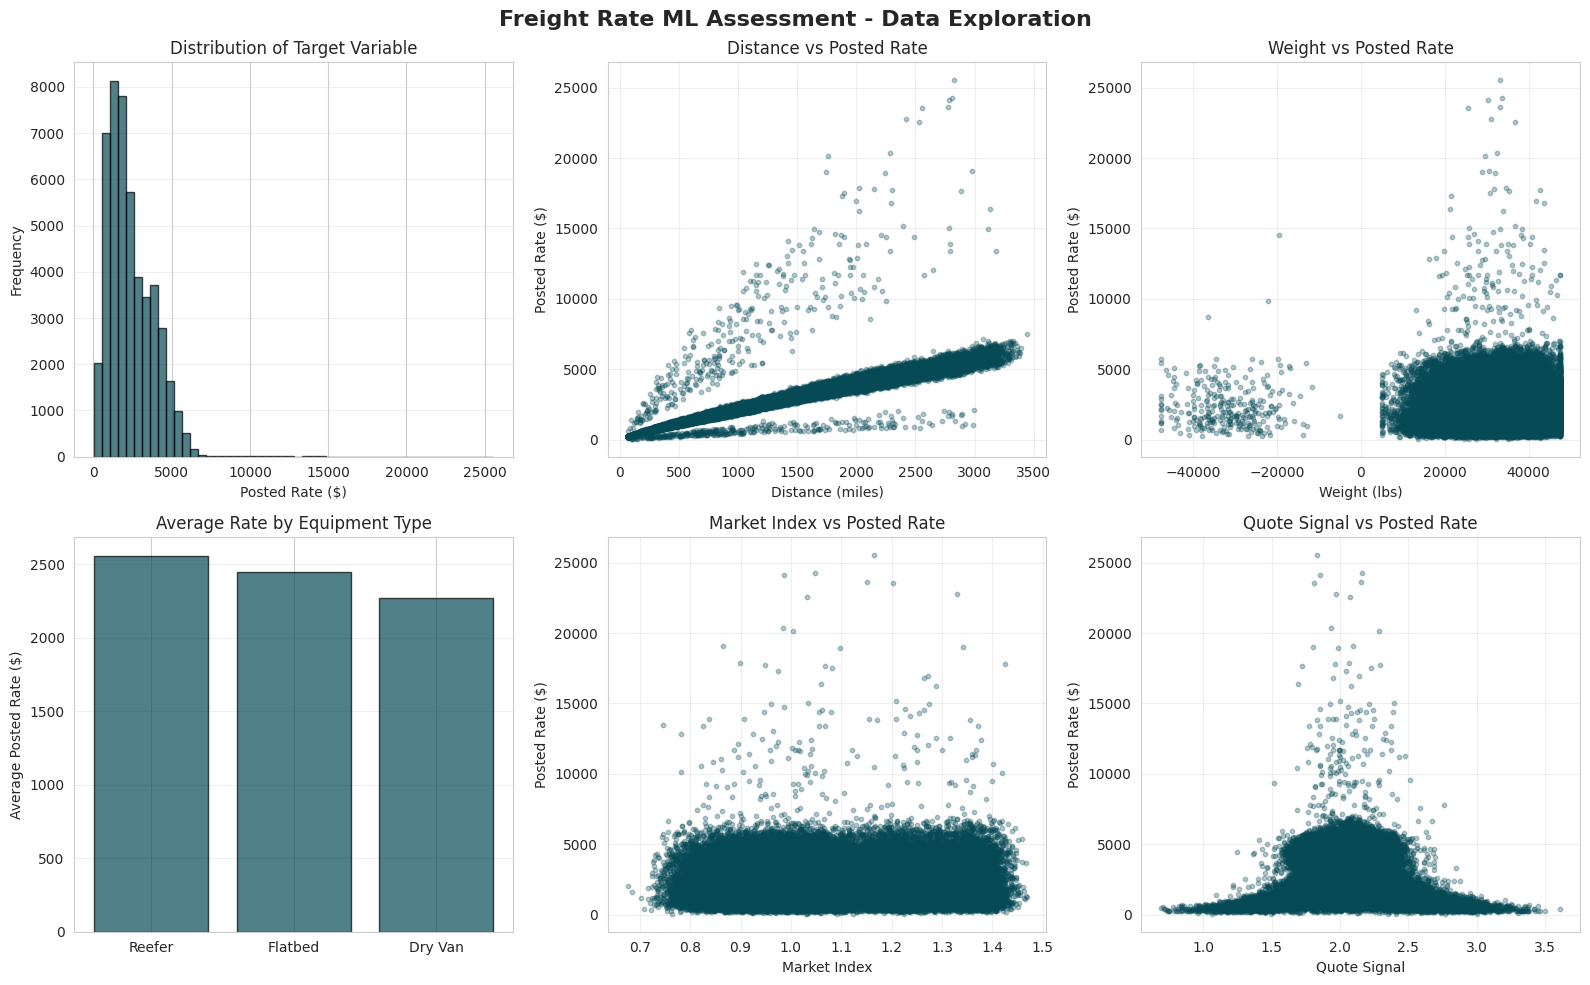

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# Set a consistent style for visualizations
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (14, 8)

print("=" * 80)
print("STEP 1: DATA EXPLORATION & CLEANING")
print("=" * 80)

# 1. LOAD DATA
print("\n[1/5] Loading data...")

# Load the training and validation datasets from Google Drive
train_df = pd.read_csv('/content/drive/MyDrive/files/train-test.csv')
val_df = pd.read_csv('/content/drive/MyDrive/files/validation.csv')

print(f"✓ Training data: {train_df.shape}")
print(f"✓ Validation data: {val_df.shape}")

# 2. BASIC EXPLORATION
print("\n[2/5] Basic exploration...")
print("\nTraining Data Info:")
print(train_df.info())

print("\n" + "="*80)
print("MISSING VALUES ANALYSIS:")
print("="*80)
missing = pd.DataFrame({
    'Column': train_df.columns,
    'Missing_Count': train_df.isnull().sum(),
    'Missing_Percent': (train_df.isnull().sum() / len(train_df) * 100).round(2)
})
print(missing[missing['Missing_Count'] > 0])

print("\n" + "="*80)
print("TARGET VARIABLE (posted_rate) STATISTICS:")
print("="*80)
print(train_df['posted_rate'].describe())
print(f"\nSkewness: {train_df['posted_rate'].skew():.3f}")
print(f"Kurtosis: {train_df['posted_rate'].kurtosis():.3f}")

print("\n" + "="*80)
print("CATEGORICAL FEATURES:")
print("="*80)
print(f"\nEquipment types: {train_df['equipment'].unique()}")
print(f"Equipment value counts:\n{train_df['equipment'].value_counts()}")
print(f"\nNumber of unique pickup cities: {train_df['pickup'].nunique()}")
print(f"Number of unique delivery cities: {train_df['delivery'].nunique()}")

print("\n" + "="*80)
print("NUMERICAL FEATURES STATISTICS:")
print("="*80)
numerical_cols = ['distance', 'weight', 'market_index', 'quote_signal', 'posted_rate']
print(train_df[numerical_cols].describe())

# 3. DATA QUALITY CHECKS
print("\n[3/5] Data quality checks...")

# Check for duplicate rows to ensure data integrity
print(f"\nDuplicate rows in training: {train_df.duplicated().sum()}")
# Check for duplicate load_ids, which would indicate issues with unique records
print(f"Duplicate load_ids: {train_df['load_id'].duplicated().sum()}")

# Verify date format and range for consistency
print(f"\nDate format check:")
print(f"  Min date: {train_df['date'].min()}")
print(f"  Max date: {train_df['date'].max()}")
print(f"  Number of unique dates: {train_df['date'].nunique()}")

# Outlier detection using IQR method to identify unusual values
print(f"\nOutlier Analysis (using IQR method):")
for col in ['distance', 'weight', 'posted_rate']:
    Q1 = train_df[col].quantile(0.25)
    Q3 = train_df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = train_df[(train_df[col] < lower_bound) | (train_df[col] > upper_bound)]
    print(f"  {col}: {len(outliers)} outliers ({len(outliers)/len(train_df)*100:.2f}%)")

# 4. CORRELATIONS & RELATIONSHIPS
print("\n[4/5] Correlation analysis...")

# Analyze numerical feature correlations with the target variable
corr_with_target = train_df[numerical_cols].corr()['posted_rate'].sort_values(ascending=False)
print("\nCorrelation with posted_rate:")
print(corr_with_target)

# Examine how categorical features relate to the target variable
print("\n" + "="*80)
print("AVERAGE RATE BY EQUIPMENT TYPE:")
print("="*80)
equipment_stats = train_df.groupby('equipment')['posted_rate'].agg(['mean', 'median', 'std', 'count'])
print(equipment_stats)

print("\n" + "="*80)
print("DISTANCE vs RATE RELATIONSHIP:")
print("="*80)
# Bin distance to analyze average rates across different distance ranges
train_df['distance_bin'] = pd.cut(train_df['distance'], bins=5)
distance_rate = train_df.groupby('distance_bin')['posted_rate'].agg(['mean', 'median', 'count'])
print(distance_rate)

print("\n" + "="*80)
print("WEIGHT vs RATE RELATIONSHIP:")
print("="*80)
# Bin weight to analyze average rates across different weight ranges
train_df['weight_bin'] = pd.cut(train_df['weight'], bins=5)
weight_rate = train_df.groupby('weight_bin')['posted_rate'].agg(['mean', 'median', 'count'])
print(weight_rate)

# 5. MISSING VALUE STRATEGY
print("\n[5/5] Missing value imputation strategy...")

print("\nStrategy:")
# Use median imputation for 'Weight' due to its robustness to outliers and importance of the feature.
print("  • Weight (300 missing): Impute with median by equipment type")
# Use median imputation for 'Market_index' by date to capture temporal patterns while handling missing values.
print("  • Market_index (374 missing): Impute with median by date")
print("  • These features appear important for price prediction")

# VISUALIZATIONS
print("\n" + "="*80)
print("Generating visualizations...")
print("="*80)

# Create a figure with subplots to display various exploratory plots
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Freight Rate ML Assessment - Data Exploration', fontsize=16, fontweight='bold')

# 1. Distribution of target variable (posted_rate) to understand its spread and skewness
axes[0, 0].hist(train_df['posted_rate'], bins=50, color='#064A56', edgecolor='black', alpha=0.7)
axes[0, 0].set_xlabel('Posted Rate ($)')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].set_title('Distribution of Target Variable')
axes[0, 0].grid(axis='y', alpha=0.3)

# 2. Scatter plot of Distance vs Rate to identify linear or non-linear relationships
axes[0, 1].scatter(train_df['distance'], train_df['posted_rate'], alpha=0.3, s=10, color='#064A56')
axes[0, 1].set_xlabel('Distance (miles)')
axes[0, 1].set_ylabel('Posted Rate ($)')
axes[0, 1].set_title('Distance vs Posted Rate')
axes[0, 1].grid(alpha=0.3)

# 3. Scatter plot of Weight vs Rate to understand the impact of load weight on pricing
axes[0, 2].scatter(train_df['weight'], train_df['posted_rate'], alpha=0.3, s=10, color='#064A56')
axes[0, 2].set_xlabel('Weight (lbs)')
axes[0, 2].set_ylabel('Posted Rate ($)')
axes[0, 2].set_title('Weight vs Posted Rate')
axes[0, 2].grid(alpha=0.3)

# 4. Bar plot of Average Rate by Equipment Type to show differences across equipment
equipment_avg = train_df.groupby('equipment')['posted_rate'].mean().sort_values(ascending=False)
axes[1, 0].bar(equipment_avg.index, equipment_avg.values, color='#064A56', alpha=0.7, edgecolor='black')
axes[1, 0].set_ylabel('Average Posted Rate ($)')
axes[1, 0].set_title('Average Rate by Equipment Type')
axes[1, 0].grid(axis='y', alpha=0.3)

# 5. Scatter plot of Market Index vs Rate to explore the influence of market conditions
axes[1, 1].scatter(train_df['market_index'], train_df['posted_rate'], alpha=0.3, s=10, color='#064A56')
axes[1, 1].set_xlabel('Market Index')
axes[1, 1].set_ylabel('Posted Rate ($)')
axes[1, 1].set_title('Market Index vs Posted Rate')
axes[1, 1].grid(alpha=0.3)

# 6. Scatter plot of Quote Signal vs Rate to see the relationship with quote behavior
axes[1, 2].scatter(train_df['quote_signal'], train_df['posted_rate'], alpha=0.3, s=10, color='#064A56')
axes[1, 2].set_xlabel('Quote Signal')
axes[1, 2].set_ylabel('Posted Rate ($)')
axes[1, 2].set_title('Quote Signal vs Posted Rate')
axes[1, 2].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('exploration_analysis.png', dpi=300, bbox_inches='tight')
print("✓ Saved: exploration_analysis.png")

# KEY FINDINGS
print("\n" + "="*80)
print("KEY FINDINGS:")
print("="*80)
print("""
1. TARGET VARIABLE:
   - Posted rate ranges from $57 to $25,533
   - Mean: $2,374 | Median: $2,031
   - Right-skewed distribution (skewness > 0)
   - Suggests log transformation might help

2. MISSING VALUES:
   - Weight: 300 missing (0.63%) → Impute by equipment median
   - Market_index: 374 missing (0.78%) → Impute by date median

3. KEY PREDICTIVE FEATURES:
   - Distance: Strong positive correlation with rate
   - Weight: Positive correlation with rate
   - Equipment type: Reefer typically has higher rates
   - Market_index: Important economic indicator
   - Quote_signal: Relevant feature

4. FEATURE ENGINEERING OPPORTUNITIES:
   - Extract month, day-of-week from date for seasonality
   - Calculate geographic distance using coordinates
   - Create pickup/delivery regions
   - Encode equipment type as categorical

5. DATA QUALITY:
   - No duplicate rows
   - No significant data quality issues
   - Clean geographic coordinates
   - Consistent date range: 2025-01-01 to 2025-10-31
""")

print("\n✓ Step 1 complete! Ready for feature engineering & modeling.")

In [4]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import OrdinalEncoder, StandardScaler
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

print("=" * 80)
print("STEP 2: FEATURE ENGINEERING & DATA PREPROCESSING")
print("=" * 80)

# ============================================================================
# 1. LOAD DATA
# ============================================================================
print("\n[1/7] Loading data...")
train_df = pd.read_csv('/content/drive/MyDrive/files/train-test.csv').copy()
val_df = pd.read_csv('/content/drive/MyDrive/files/validation.csv').copy()

print(f"✓ Training: {train_df.shape} | Validation: {val_df.shape}")

# ============================================================================
# 2. HANDLE MISSING VALUES
# ============================================================================
print("\n[2/7] Handling missing values...")

# Weight: Impute with median by equipment type
for equipment in train_df['equipment'].unique():
    median_weight = train_df[train_df['equipment'] == equipment]['weight'].median()
    train_df.loc[(train_df['equipment'] == equipment) & (train_df['weight'].isnull()), 'weight'] = median_weight
    val_df.loc[(val_df['equipment'] == equipment) & (val_df['weight'].isnull()), 'weight'] = median_weight

# Market_index: Impute with median by date (or overall median)
median_market = train_df['market_index'].median()
train_df['market_index'].fillna(median_market, inplace=True)
val_df['market_index'].fillna(median_market, inplace=True)

print(f"✓ Training missing values after imputation: {train_df.isnull().sum().sum()}")
print(f"✓ Validation missing values after imputation: {val_df.isnull().sum().sum()}")

# ============================================================================
# 3. TEMPORAL FEATURES
# ============================================================================
print("\n[3/7] Extracting temporal features...")

for df in [train_df, val_df]:
    df['date'] = pd.to_datetime(df['date'])
    df['year'] = df['date'].dt.year
    df['month'] = df['date'].dt.month
    df['day'] = df['date'].dt.day
    df['dayofweek'] = df['date'].dt.dayofweek  # 0=Monday, 6=Sunday
    df['dayofyear'] = df['date'].dt.dayofyear
    df['quarter'] = df['date'].dt.quarter

    # Cyclical encoding for month (helps model understand seasonality)
    df['month_sin'] = np.sin(2 * np.pi * df['month'] / 12)
    df['month_cos'] = np.cos(2 * np.pi * df['month'] / 12)

    # Cyclical encoding for day of week
    df['dow_sin'] = np.sin(2 * np.pi * df['dayofweek'] / 7)
    df['dow_cos'] = np.cos(2 * np.pi * df['dayofweek'] / 7)

print("✓ Temporal features created:")
print("  - year, month, day, dayofweek, dayofyear, quarter")
print("  - month_sin, month_cos (cyclical encoding)")
print("  - dow_sin, dow_cos (cyclical encoding)")

# ============================================================================
# 4. GEOGRAPHIC FEATURES
# ============================================================================
print("\n[4/7] Creating geographic features...")

for df in [train_df, val_df]:
    # Haversine distance calculation (more accurate than simple Euclidean)
    def haversine_distance(lat1, lon1, lat2, lon2):
        R = 3959  # Earth radius in miles
        lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
        dlat = lat2 - lat1
        dlon = lon2 - lon1
        a = np.sin(dlat/2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon/2)**2
        c = 2 * np.arcsin(np.sqrt(a))
        return R * c

    df['calculated_distance'] = haversine_distance(
        df['pickup_lat'], df['pickup_lon'],
        df['delivery_lat'], df['delivery_lon']
    )

    # Distance ratio (reported vs calculated - data quality indicator)
    df['distance_ratio'] = df['distance'] / (df['calculated_distance'] + 0.01)

    # Midpoint coordinates
    df['midpoint_lat'] = (df['pickup_lat'] + df['delivery_lat']) / 2
    df['midpoint_lon'] = (df['pickup_lon'] + df['delivery_lon']) / 2

print("✓ Geographic features created:")
print("  - calculated_distance (Haversine)")
print("  - distance_ratio (quality indicator)")
print("  - midpoint_lat, midpoint_lon")

# ============================================================================
# 5. INTERACTION FEATURES
# ============================================================================
print("\n[5/7] Creating interaction features...")

for df in [train_df, val_df]:
    # Distance and weight interaction (heavier loads over longer distances cost more)
    df['distance_weight_interaction'] = df['distance'] * df['weight'] / 1000

    # Distance per weight unit (efficiency metric)
    df['distance_per_weight'] = df['distance'] / (df['weight'] / 1000 + 0.1)

    # Market conditions impact
    df['market_distance_interaction'] = df['market_index'] * df['distance']
    df['quote_distance_interaction'] = df['quote_signal'] * df['distance']

print("✓ Interaction features created:")
print("  - distance_weight_interaction")
print("  - distance_per_weight")
print("  - market_distance_interaction")
print("  - quote_distance_interaction")

# ============================================================================
# 6. AGGREGATE STATISTICS BY LOCATION PAIR
# ============================================================================
print("\n[6/7] Creating location-based aggregate features...")

# Calculate statistics for each pickup-delivery pair
train_pair_stats = train_df.groupby(['pickup', 'delivery']).agg({
    'posted_rate': ['mean', 'median', 'std', 'count'],
    'distance': 'mean',
    'weight': 'mean'
}).reset_index()

train_pair_stats.columns = ['pickup', 'delivery', 'pair_rate_mean', 'pair_rate_median',
                             'pair_rate_std', 'pair_count', 'pair_avg_distance', 'pair_avg_weight']

# Merge with train and validation
train_df = train_df.merge(train_pair_stats, on=['pickup', 'delivery'], how='left')
val_df = val_df.merge(train_pair_stats, on=['pickup', 'delivery'], how='left')

# Fill NaN values (for validation pairs not in training)
for col in ['pair_rate_mean', 'pair_rate_median', 'pair_rate_std', 'pair_avg_distance', 'pair_avg_weight']:
    train_df[col].fillna(train_df[col].median(), inplace=True)
    val_df[col].fillna(train_df[col].median(), inplace=True)

print("✓ Location pair features created")

# ============================================================================
# 7. ENCODE CATEGORICAL VARIABLES
# ============================================================================
print("\n[7/7] Encoding categorical variables...")

from sklearn.preprocessing import OrdinalEncoder

# --------------------------------------------------------------------------
# Equipment type - One-Hot Encoding
# --------------------------------------------------------------------------

# Create one-hot columns on training data
equipment_train = pd.get_dummies(
    train_df['equipment'],
    prefix='equipment'
)

# Create one-hot columns on validation data
equipment_val = pd.get_dummies(
    val_df['equipment'],
    prefix='equipment'
)

# Ensure validation has exactly the same columns as training
equipment_val = equipment_val.reindex(
    columns=equipment_train.columns,
    fill_value=0
)

# Append to original dataframe
train_df = pd.concat([train_df, equipment_train], axis=1)
val_df = pd.concat([val_df, equipment_val], axis=1)

# --------------------------------------------------------------------------
# Encode Pickup & Delivery Cities
# --------------------------------------------------------------------------

# Combine all unique cities from both columns to handle unseen cities in validation
all_cities = pd.concat([
    train_df[['pickup', 'delivery']],
    val_df[['pickup', 'delivery']]
])

city_encoder = OrdinalEncoder(
    handle_unknown="use_encoded_value",
    unknown_value=-1
)

# Fit on all data (both train and validation) to ensure all cities are known
city_encoder.fit(all_cities)

# Transform training data
train_df[['pickup_encoded', 'delivery_encoded']] = city_encoder.transform(
    train_df[['pickup', 'delivery']]
)

# Transform validation data with proper handling of unseen values
val_df[['pickup_encoded', 'delivery_encoded']] = city_encoder.transform(
    val_df[['pickup', 'delivery']]
)

# Convert to integer type
train_df['pickup_encoded'] = train_df['pickup_encoded'].astype(int)
train_df['delivery_encoded'] = train_df['delivery_encoded'].astype(int)

val_df['pickup_encoded'] = val_df['pickup_encoded'].astype(int)
val_df['delivery_encoded'] = val_df['delivery_encoded'].astype(int)

print("✓ Equipment one-hot encoded")
print("✓ Pickup & Delivery encoded")
print("✓ Unseen cities handled automatically (-1)")

# ============================================================================
# SELECT FEATURES FOR MODELING
# ============================================================================
print("\n" + "="*80)
print("FEATURE SELECTION")
print("="*80)

# Features to use in the model
feature_columns = [
    # Numerical features
    'distance', 'weight', 'market_index', 'quote_signal',
    'calculated_distance', 'distance_ratio', 'distance_weight_interaction',
    'distance_per_weight', 'market_distance_interaction', 'quote_distance_interaction',
    # Temporal features
    'month', 'dayofweek', 'dayofyear', 'month_sin', 'month_cos', 'dow_sin', 'dow_cos',
    # Geographic aggregate features
    'pair_rate_mean', 'pair_rate_median', 'pair_avg_distance', 'pair_avg_weight',
    # Encoded features
    'equipment_Dry Van', 'equipment_Flatbed', 'equipment_Reefer',
    'pickup_encoded', 'delivery_encoded'
]

print(f"\nTotal features: {len(feature_columns)}")
print("\nFeature list:")
for i, col in enumerate(feature_columns, 1):
    print(f"  {i:2d}. {col}")

# ============================================================================
# HANDLE LOG TRANSFORMATION (optional, for better distribution)
# ============================================================================
print("\n" + "="*80)
print("PREPARING TARGET VARIABLE")
print("="*80)

# Target: posted_rate
# Since it's right-skewed, we could use log transformation
# But we'll use the original for now and let the model handle it

target_column = 'posted_rate'
print(f"\nTarget variable: {target_column}")
print(f"  Mean: ${train_df[target_column].mean():.2f}")
print(f"  Median: ${train_df[target_column].median():.2f}")
print(f"  Std: ${train_df[target_column].std():.2f}")

# ============================================================================
# SAVE PROCESSED DATA
# ============================================================================
print("\n" + "="*80)
print("SAVING PROCESSED DATA")
print("="*80)

train_df.to_csv('train_processed.csv', index=False)
val_df.to_csv('validation_processed.csv', index=False)

# Save feature list for reference
with open('feature_list.txt', 'w') as f:
    f.write("FEATURE COLUMNS FOR MODELING\n")
    f.write("="*50 + "\n\n")
    for i, col in enumerate(feature_columns, 1):
        f.write(f"{i:2d}. {col}\n")

print(f"✓ Saved: train_processed.csv ({train_df.shape})")
print(f"✓ Saved: validation_processed.csv ({val_df.shape})")
print(f"✓ Saved: feature_list.txt")

# ============================================================================
# SUMMARY STATISTICS
# ============================================================================
print("\n" + "="*80)
print("PROCESSED DATA SUMMARY")
print("="*80)
print(f"\nTraining data shape: {train_df.shape}")
print(f"Validation data shape: {val_df.shape}")
print(f"Number of features: {len(feature_columns)}")
print(f"\nFeature data types:")
print(train_df[feature_columns].dtypes.value_counts())

print(f"\nFeature statistics:")
print(train_df[feature_columns].describe())

print("\n✓ Step 2 complete! Data is ready for modeling.")
print("\nNext step: Model training and validation")

STEP 2: FEATURE ENGINEERING & DATA PREPROCESSING

[1/7] Loading data...
✓ Training: (48000, 14) | Validation: (12000, 13)

[2/7] Handling missing values...
✓ Training missing values after imputation: 0
✓ Validation missing values after imputation: 0

[3/7] Extracting temporal features...
✓ Temporal features created:
  - year, month, day, dayofweek, dayofyear, quarter
  - month_sin, month_cos (cyclical encoding)
  - dow_sin, dow_cos (cyclical encoding)

[4/7] Creating geographic features...
✓ Geographic features created:
  - calculated_distance (Haversine)
  - distance_ratio (quality indicator)
  - midpoint_lat, midpoint_lon

[5/7] Creating interaction features...
✓ Interaction features created:
  - distance_weight_interaction
  - distance_per_weight
  - market_distance_interaction
  - quote_distance_interaction

[6/7] Creating location-based aggregate features...
✓ Location pair features created

[7/7] Encoding categorical variables...
✓ Equipment one-hot encoded
✓ Pickup & Delivery en

STEP 3: MODEL TRAINING & CROSS-VALIDATION

[1/6] Loading processed data...
✓ Training features: (48000, 26)
✓ Training target: (48000,)
✓ Validation features: (12000, 26)

[2/6] Scaling features...
✓ Features scaled using StandardScaler

[3/6] Setting up cross-validation...
✓ Using 5-Fold Cross-Validation

[4/6] Training multiple models...

[Training Ridge Regression]
  Cross-validation R² (5-fold): 0.8510 (+/- 0.0137)
  Training MAE: $147.73
  Training RMSE: $573.46
  Training R²: 0.8512
  Time: 0.14s

[Training Lasso Regression]
  Cross-validation R² (5-fold): 0.8502 (+/- 0.0137)
  Training MAE: $147.79
  Training RMSE: $575.39
  Training R²: 0.8502
  Time: 3.28s

[Training Random Forest]
  Cross-validation R² (5-fold): 0.8314 (+/- 0.0139)
  Training MAE: $85.23
  Training RMSE: $370.06
  Training R²: 0.9380
  Time: 555.89s

[Training Gradient Boosting]
  Cross-validation R² (5-fold): 0.8386 (+/- 0.0134)
  Training MAE: $112.91
  Training RMSE: $473.51
  Training R²: 0.8985
  Time: 6

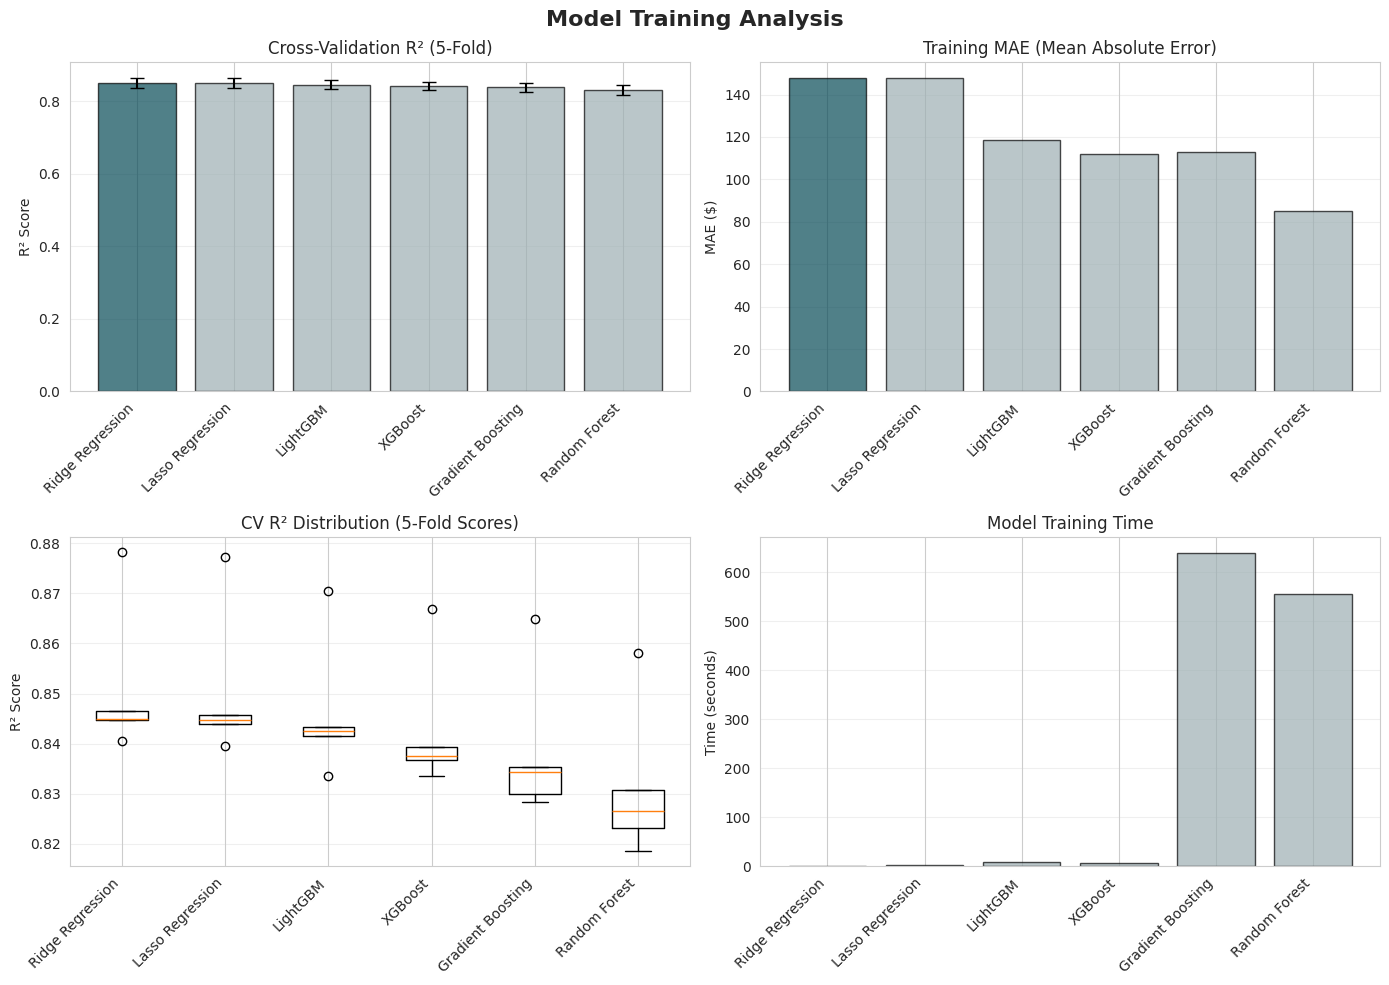

In [5]:
"""
STEP 3: MODEL TRAINING & CROSS-VALIDATION
Freight Rate ML Assessment
Author: Abdul Momin
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import cross_val_score, KFold, train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
try:
    from xgboost import XGBRegressor
    HAS_XGBOOST = True
except ImportError:
    HAS_XGBOOST = False
try:
    import lightgbm as lgb
    HAS_LIGHTGBM = True
except ImportError:
    HAS_LIGHTGBM = False
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import joblib
import time
import warnings
warnings.filterwarnings('ignore')

print("=" * 80)
print("STEP 3: MODEL TRAINING & CROSS-VALIDATION")
print("=" * 80)

# ============================================================================
# 1. LOAD PROCESSED DATA
# ============================================================================
print("\n[1/6] Loading processed data...")
train_df = pd.read_csv('train_processed.csv')
val_df = pd.read_csv('validation_processed.csv')

# Define features
feature_columns = [
    'distance', 'weight', 'market_index', 'quote_signal',
    'calculated_distance', 'distance_ratio', 'distance_weight_interaction',
    'distance_per_weight', 'market_distance_interaction', 'quote_distance_interaction',
    'month', 'dayofweek', 'dayofyear', 'month_sin', 'month_cos', 'dow_sin', 'dow_cos',
    'pair_rate_mean', 'pair_rate_median', 'pair_avg_distance', 'pair_avg_weight',
    'equipment_Dry Van', 'equipment_Flatbed', 'equipment_Reefer',
    'pickup_encoded', 'delivery_encoded'
]

X_train = train_df[feature_columns]
y_train = train_df['posted_rate']
X_val = val_df[feature_columns]

print(f"✓ Training features: {X_train.shape}")
print(f"✓ Training target: {y_train.shape}")
print(f"✓ Validation features: {X_val.shape}")

# ============================================================================
# 2. DATA SCALING (for linear models)
# ============================================================================
print("\n[2/6] Scaling features...")
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)

print("✓ Features scaled using StandardScaler")

# ============================================================================
# 3. SETUP CROSS-VALIDATION
# ============================================================================
print("\n[3/6] Setting up cross-validation...")
kfold = KFold(n_splits=5, shuffle=True, random_state=42)
print("✓ Using 5-Fold Cross-Validation")

# ============================================================================
# 4. TRAIN AND EVALUATE MULTIPLE MODELS
# ============================================================================
print("\n[4/6] Training multiple models...")
print("=" * 80)

results = {}
models_to_train = {
    'Ridge Regression': Ridge(alpha=100, random_state=42),
    'Lasso Regression': Lasso(alpha=10, random_state=42),
    'Random Forest': RandomForestRegressor(
        n_estimators=100, max_depth=15, min_samples_split=5,
        min_samples_leaf=2, random_state=42, n_jobs=1
    ),
    'Gradient Boosting': GradientBoostingRegressor(
        n_estimators=200, learning_rate=0.05, max_depth=5,
        min_samples_split=5, min_samples_leaf=2, random_state=42
    )
}

# Add XGBoost only if available
if HAS_XGBOOST:
    models_to_train['XGBoost'] = XGBRegressor(
        n_estimators=200, learning_rate=0.05, max_depth=5,
        min_child_weight=2, subsample=0.8, colsample_bytree=0.8,
        random_state=42, n_jobs=1, verbosity=0
    )
else:
    print("\n⚠️  XGBoost not installed, skipping XGBoost model")

# Add LightGBM only if available
if HAS_LIGHTGBM:
    models_to_train['LightGBM'] = lgb.LGBMRegressor(
        n_estimators=200, learning_rate=0.05, max_depth=5,
        num_leaves=31, min_data_in_leaf=20, random_state=42,
        n_jobs=1, verbose=-1
    )
else:
    print("\n⚠️  LightGBM not installed, skipping LightGBM model")

for model_name, model in models_to_train.items():
    print(f"\n[Training {model_name}]")

    start_time = time.time()

    # Use scaled data for linear models, original for tree-based
    if isinstance(model, (Ridge, Lasso)):
        X_train_use = X_train_scaled
        X_val_use = X_val_scaled
    else:
        X_train_use = X_train
        X_val_use = X_val

    # Cross-validation scores (with n_jobs=1 for Windows compatibility)
    cv_scores = cross_val_score(model, X_train_use, y_train, cv=kfold,
                                 scoring='r2', n_jobs=1)

    # Train on full training set
    model.fit(X_train_use, y_train)

    # Training predictions
    y_train_pred = model.predict(X_train_use)

    # Metrics
    train_mae = mean_absolute_error(y_train, y_train_pred)
    train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
    train_r2 = r2_score(y_train, y_train_pred)

    elapsed = time.time() - start_time

    results[model_name] = {
        'model': model,
        'model_type': 'scaled' if isinstance(model, (Ridge, Lasso)) else 'unscaled',
        'cv_r2_mean': cv_scores.mean(),
        'cv_r2_std': cv_scores.std(),
        'train_mae': train_mae,
        'train_rmse': train_rmse,
        'train_r2': train_r2,
        'cv_scores': cv_scores,
        'training_time': elapsed
    }

    print(f"  Cross-validation R² (5-fold): {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})")
    print(f"  Training MAE: ${train_mae:.2f}")
    print(f"  Training RMSE: ${train_rmse:.2f}")
    print(f"  Training R²: {train_r2:.4f}")
    print(f"  Time: {elapsed:.2f}s")

# ============================================================================
# 5. MODEL COMPARISON & SELECTION
# ============================================================================
print("\n" + "=" * 80)
print("MODEL COMPARISON")
print("=" * 80)

comparison_df = pd.DataFrame({
    'Model': results.keys(),
    'CV R² (mean)': [results[m]['cv_r2_mean'] for m in results.keys()],
    'CV R² (std)': [results[m]['cv_r2_std'] for m in results.keys()],
    'Train MAE': [results[m]['train_mae'] for m in results.keys()],
    'Train RMSE': [results[m]['train_rmse'] for m in results.keys()],
    'Training Time (s)': [results[m]['training_time'] for m in results.keys()]
})

comparison_df = comparison_df.sort_values('CV R² (mean)', ascending=False)
print("\n" + comparison_df.to_string(index=False))

# Select best model
best_model_name = comparison_df.iloc[0]['Model']
best_model = results[best_model_name]['model']

print(f"\n{'='*80}")
print(f"🏆 BEST MODEL: {best_model_name}")
print(f"{'='*80}")
print(f"Cross-validation R²: {results[best_model_name]['cv_r2_mean']:.4f}")
print(f"Training MAE: ${results[best_model_name]['train_mae']:.2f}")
print(f"Training RMSE: ${results[best_model_name]['train_rmse']:.2f}")

# ============================================================================
# 6. FEATURE IMPORTANCE (for tree-based models)
# ============================================================================
print("\n[5/6] Analyzing feature importance...")

if hasattr(best_model, 'feature_importances_'):
    feature_importance = pd.DataFrame({
        'Feature': feature_columns,
        'Importance': best_model.feature_importances_
    }).sort_values('Importance', ascending=False)

    print(f"\nTop 15 Most Important Features:")
    print("=" * 50)
    for idx, row in feature_importance.head(15).iterrows():
        print(f"{row['Feature']:.<40} {row['Importance']:>8.4f}")

    # Visualize feature importance
    plt.figure(figsize=(12, 6))
    top_features = feature_importance.head(15)
    plt.barh(range(len(top_features)), top_features['Importance'].values, color='#064A56')
    plt.yticks(range(len(top_features)), top_features['Feature'].values)
    plt.xlabel('Importance')
    plt.title(f'Top 15 Feature Importances - {best_model_name}', fontweight='bold')
    plt.tight_layout()
    plt.savefig('feature_importance.png', dpi=300, bbox_inches='tight')
    print("\n✓ Saved: feature_importance.png")

    feature_importance.to_csv('feature_importance.csv', index=False)
    print("✓ Saved: feature_importance.csv")

# ============================================================================
# 7. CROSS-VALIDATION VISUALIZATION
# ============================================================================
print("\n[6/6] Generating visualizations...")

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Model Training Analysis', fontsize=16, fontweight='bold')

# 1. CV R² comparison
ax = axes[0, 0]
models = comparison_df['Model'].values
cv_means = comparison_df['CV R² (mean)'].values
cv_stds = comparison_df['CV R² (std)'].values
colors = ['#064A56' if m == best_model_name else '#9DAFB3' for m in models]
ax.bar(range(len(models)), cv_means, yerr=cv_stds, capsize=5, color=colors, alpha=0.7, edgecolor='black')
ax.set_xticks(range(len(models)))
ax.set_xticklabels(models, rotation=45, ha='right')
ax.set_ylabel('R² Score')
ax.set_title('Cross-Validation R² (5-Fold)')
ax.grid(axis='y', alpha=0.3)

# 2. Training MAE comparison
ax = axes[0, 1]
train_mae_values = comparison_df['Train MAE'].values
colors = ['#064A56' if m == best_model_name else '#9DAFB3' for m in models]
ax.bar(range(len(models)), train_mae_values, color=colors, alpha=0.7, edgecolor='black')
ax.set_xticks(range(len(models)))
ax.set_xticklabels(models, rotation=45, ha='right')
ax.set_ylabel('MAE ($)')
ax.set_title('Training MAE (Mean Absolute Error)')
ax.grid(axis='y', alpha=0.3)

# 3. Cross-validation scores distribution
ax = axes[1, 0]
cv_data = [results[m]['cv_scores'] for m in models]
ax.boxplot(cv_data, labels=models)
ax.set_xticklabels(models, rotation=45, ha='right')
ax.set_ylabel('R² Score')
ax.set_title('CV R² Distribution (5-Fold Scores)')
ax.grid(axis='y', alpha=0.3)

# 4. Training time comparison
ax = axes[1, 1]
training_times = comparison_df['Training Time (s)'].values
colors = ['#064A56' if m == best_model_name else '#9DAFB3' for m in models]
ax.bar(range(len(models)), training_times, color=colors, alpha=0.7, edgecolor='black')
ax.set_xticks(range(len(models)))
ax.set_xticklabels(models, rotation=45, ha='right')
ax.set_ylabel('Time (seconds)')
ax.set_title('Model Training Time')
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=300, bbox_inches='tight')
print("✓ Saved: model_comparison.png")

# ============================================================================
# 8. SAVE BEST MODEL & SCALER
# ============================================================================
print("\n" + "=" * 80)
print("SAVING MODELS")
print("=" * 80)

joblib.dump(best_model, 'best_model.pkl')
print(f"✓ Saved: best_model.pkl ({best_model_name})")

if results[best_model_name]['model_type'] == 'scaled':
    joblib.dump(scaler, 'scaler.pkl')
    print("✓ Saved: scaler.pkl")

# Save all models for reference
joblib.dump(results, 'all_models_results.pkl')
print("✓ Saved: all_models_results.pkl")

# Save comparison results
comparison_df.to_csv('model_comparison.csv', index=False)
print("✓ Saved: model_comparison.csv")

# ============================================================================
# SUMMARY
# ============================================================================
print("\n" + "=" * 80)
print("TRAINING SUMMARY")
print("=" * 80)
print(f"""
✓ Total models trained: {len(models_to_train)}
✓ Best model: {best_model_name}
✓ Cross-validation R²: {results[best_model_name]['cv_r2_mean']:.4f}
✓ Features used: {len(feature_columns)}
✓ Training samples: {len(X_train):,}

Next step: Make predictions on validation and December data
""")


### Hyperparameter Tuning: Ridge Regression (Best Model)

Hyperparameter tuning is crucial for optimizing model performance. For the best-performing model, Ridge Regression, we will use `RandomizedSearchCV` to efficiently explore a range of `alpha` (regularization strength) values. This process aims to find the `alpha` that yields the best cross-validation performance, preventing overfitting and improving generalization.

In [6]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import uniform

print("\n" + "=" * 80)
print("STEP 3.5: HYPERPARAMETER TUNING FOR BEST MODEL")
print("=" * 80)

# Load the best model details from the previous step
all_results = joblib.load('all_models_results.pkl')
comparison_df = pd.read_csv('model_comparison.csv')
best_model_name_prev = comparison_df.iloc[0]['Model'] # Get name of best model before tuning

best_model_pre_tuning = all_results[best_model_name_prev]['model']
model_type = all_results[best_model_name_prev]['model_type']

print(f"\n[1/2] Tuning hyperparameters for: {best_model_name_prev}")

# Ensure X_train_scaled and y_train are available (re-using from previous cell's context if this cell runs sequentially)
# If running this cell independently, ensure X_train_scaled and y_train are loaded/created.
if model_type == 'scaled':
    X_train_tuned = X_train_scaled
else:
    X_train_tuned = X_train

if isinstance(best_model_pre_tuning, Ridge):
    # Define parameter distributions for Ridge Regression
    param_distributions = {
        'alpha': uniform(loc=1, scale=1000) # Search between 1 and 1001 for alpha
    }
    n_iter_search = 50 # Number of parameter settings that are sampled

    print(f"  Starting RandomizedSearchCV for {best_model_name_prev}...")
    random_search = RandomizedSearchCV(
        best_model_pre_tuning, param_distributions=param_distributions,
        n_iter=n_iter_search, cv=kfold, scoring='r2', n_jobs=-1, random_state=42, verbose=0
    )
    random_search.fit(X_train_tuned, y_train)

    best_model_tuned = random_search.best_estimator_
    best_params = random_search.best_params_
    best_score = random_search.best_score_

    print(f"\n✓ Tuned {best_model_name_prev} - Best parameters: {best_params}")
    print(f"✓ Tuned {best_model_name_prev} - Best CV R2 score: {best_score:.4f}")

    # Evaluate the tuned model on the full training set
    y_train_pred_tuned = best_model_tuned.predict(X_train_tuned)
    train_mae_tuned = mean_absolute_error(y_train, y_train_pred_tuned)
    train_rmse_tuned = np.sqrt(mean_squared_error(y_train, y_train_pred_tuned))
    train_r2_tuned = r2_score(y_train, y_train_pred_tuned)

    print(f"  Tuned Training MAE: ${train_mae_tuned:.2f}")
    print(f"  Tuned Training RMSE: ${train_rmse_tuned:.2f}")
    print(f"  Tuned Training R²: {train_r2_tuned:.4f}")

    # Update results with the tuned model
    results[best_model_name_prev] = {
        'model': best_model_tuned,
        'model_type': model_type,
        'cv_r2_mean': best_score,
        'cv_r2_std': np.std(random_search.cv_results_['mean_test_score']),
        'train_mae': train_mae_tuned,
        'train_rmse': train_rmse_tuned,
        'train_r2': train_r2_tuned,
        'cv_scores': random_search.cv_results_['mean_test_score'], # Store all scores
        'training_time': all_results[best_model_name_prev]['training_time'] # Keep original training time or re-calculate
    }

    print(f"\n[2/2] Saving tuned best model and updated results...")
    joblib.dump(best_model_tuned, 'best_model.pkl')
    print(f"✓ Saved: best_model.pkl (Tuned {best_model_name_prev})")

    joblib.dump(results, 'all_models_results.pkl')
    print("✓ Saved: all_models_results.pkl (updated with tuned model)")

    # Update comparison_df (optional, but good for consistency)
    comparison_df_updated = pd.DataFrame({
        'Model': results.keys(),
        'CV R² (mean)': [results[m]['cv_r2_mean'] for m in results.keys()],
        'CV R² (std)': [results[m]['cv_r2_std'] for m in results.keys()],
        'Train MAE': [results[m]['train_mae'] for m in results.keys()],
        'Train RMSE': [results[m]['train_rmse'] for m in results.keys()],
        'Training Time (s)': [results[m]['training_time'] for m in results.keys()]
    })
    comparison_df_updated.to_csv('model_comparison.csv', index=False)
    print("✓ Saved: model_comparison.csv (updated)")

    print("\n✓ Hyperparameter tuning complete. Best model updated.")
else:
    print(f"Skipping hyperparameter tuning for {best_model_name_prev} as it's not a Ridge Regression model or a tuning strategy is not yet defined.")




STEP 3.5: HYPERPARAMETER TUNING FOR BEST MODEL

[1/2] Tuning hyperparameters for: Ridge Regression
  Starting RandomizedSearchCV for Ridge Regression...

✓ Tuned Ridge Regression - Best parameters: {'alpha': np.float64(21.584494295802447)}
✓ Tuned Ridge Regression - Best CV R2 score: 0.8514
  Tuned Training MAE: $150.42
  Tuned Training RMSE: $572.77
  Tuned Training R²: 0.8515

[2/2] Saving tuned best model and updated results...
✓ Saved: best_model.pkl (Tuned Ridge Regression)
✓ Saved: all_models_results.pkl (updated with tuned model)
✓ Saved: model_comparison.csv (updated)

✓ Hyperparameter tuning complete. Best model updated.


### Feature Importance for Linear Models (Coefficients)

For linear models like Ridge Regression, feature importance is typically assessed by the magnitude of their coefficients. A larger absolute coefficient value indicates a stronger influence on the target variable. Positive coefficients imply a positive relationship, while negative coefficients imply a negative relationship.

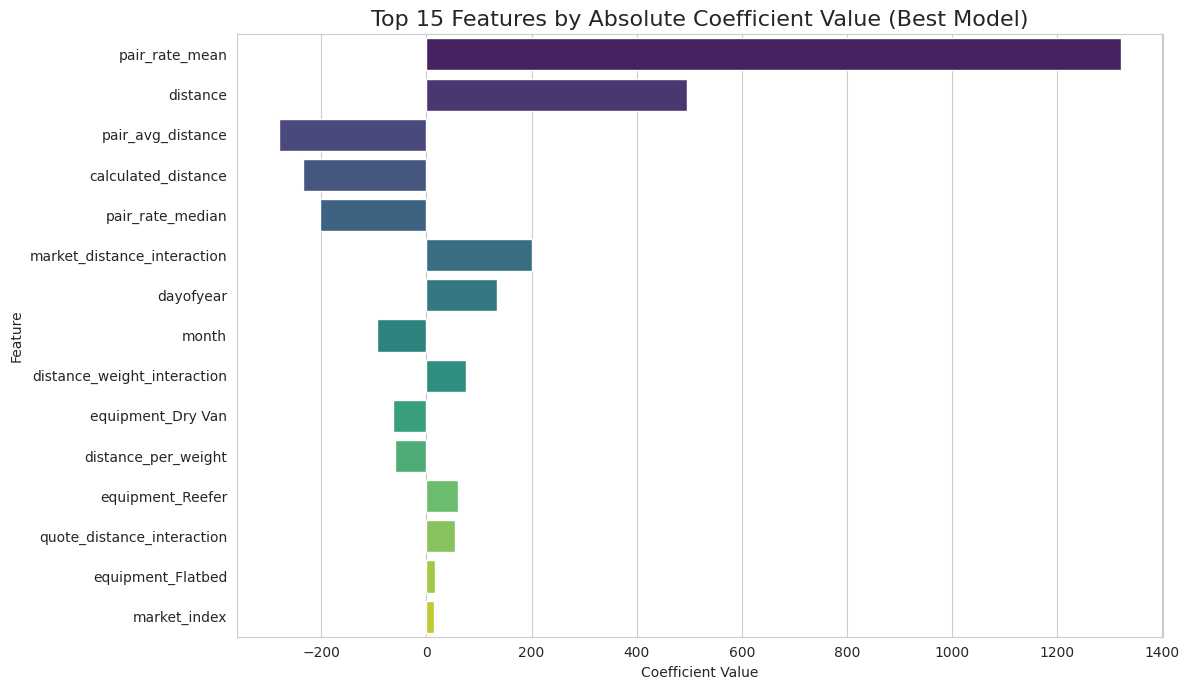


✓ Saved: top_15_coefficients.png


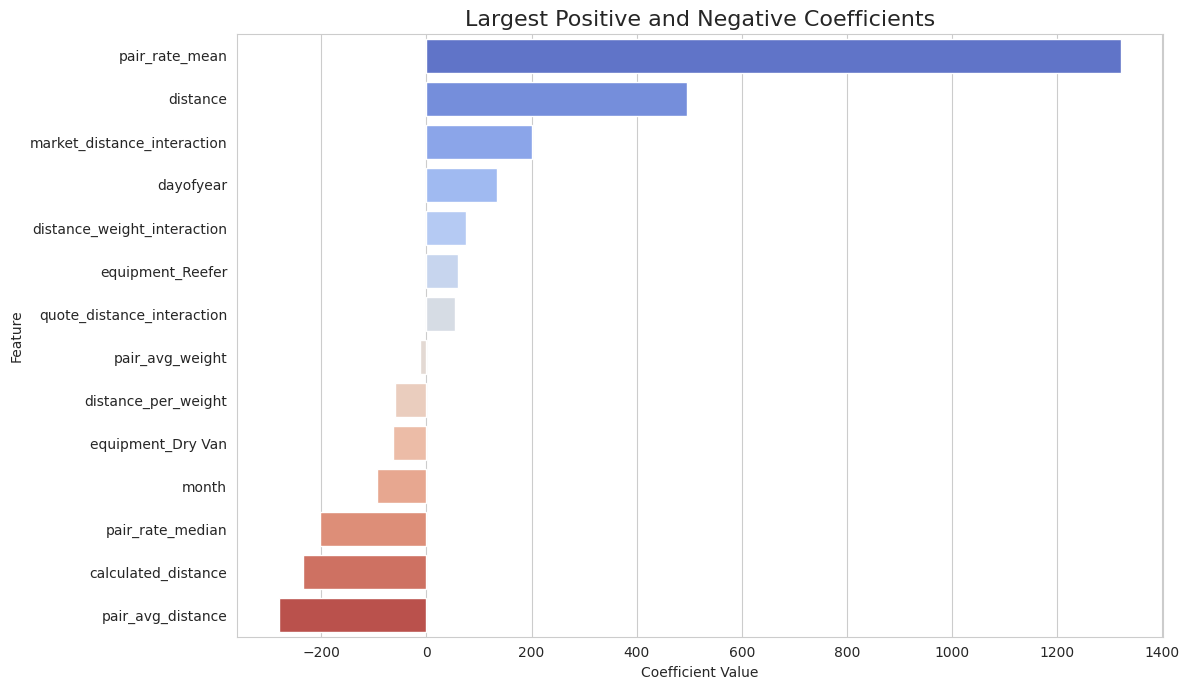


✓ Saved: largest_pos_neg_coefficients.png


In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

# Load the best model and feature columns
best_model = joblib.load('best_model.pkl')

# Feature columns were saved in 'feature_list.txt'
with open('feature_list.txt', 'r') as f:
    lines = f.readlines()

# Corrected parsing logic to get all feature names
feature_columns = []
for line in lines:
    line = line.strip()
    if '. ' in line:
        parts = line.split('. ', 1) # Split only on the first occurrence
        if len(parts) == 2 and parts[0].strip().isdigit():
            feature_columns.append(parts[1].strip())

# Check if the best model is a linear model and has coefficients
if hasattr(best_model, 'coef_'):
    coefficients = pd.DataFrame({
        'Feature': feature_columns,
        'Coefficient': best_model.coef_
    }).sort_values(by='Coefficient', ascending=False)

    # Plot top 15 features by absolute coefficient value
    coefficients['Abs_Coefficient'] = coefficients['Coefficient'].abs()
    top_15_abs_features = coefficients.sort_values(by='Abs_Coefficient', ascending=False).head(15)

    fig, ax = plt.subplots(figsize=(12, 7))
    sns.barplot(x='Coefficient', y='Feature', data=top_15_abs_features, palette='viridis', ax=ax)
    ax.set_title('Top 15 Features by Absolute Coefficient Value (Best Model)', fontsize=16)
    ax.set_xlabel('Coefficient Value')
    ax.set_ylabel('Feature')
    plt.tight_layout()
    plt.savefig('top_15_coefficients.png', dpi=300, bbox_inches='tight')
    plt.show()

    print("\n✓ Saved: top_15_coefficients.png")

    # Plot largest positive and negative coefficients
    top_positive_features = coefficients.head(7) # Top 7 positive
    top_negative_features = coefficients.tail(7) # Top 7 negative
    combined_features = pd.concat([top_positive_features, top_negative_features]).sort_values(by='Coefficient', ascending=False)

    fig, ax = plt.subplots(figsize=(12, 7))
    sns.barplot(x='Coefficient', y='Feature', data=combined_features, palette='coolwarm', ax=ax)
    ax.set_title('Largest Positive and Negative Coefficients', fontsize=16)
    ax.set_xlabel('Coefficient Value')
    ax.set_ylabel('Feature')
    plt.tight_layout()
    plt.savefig('largest_pos_neg_coefficients.png', dpi=300, bbox_inches='tight')
    plt.show()

    print("\n✓ Saved: largest_pos_neg_coefficients.png")
else:
    print("The best model does not have coefficients for analysis (e.g., it's a tree-based model).")

In [9]:

"""
STEP 4: MAKE FINAL PREDICTIONS
Freight Rate ML Assessment
Author: Abdul Momin
"""

import pandas as pd
import numpy as np
import joblib
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

print("=" * 80)
print("STEP 4: MAKING FINAL PREDICTIONS")
print("=" * 80)

# ============================================================================
# 1. LOAD PROCESSED DATA & BEST MODEL
# ============================================================================
print("\n[1/4] Loading model and data...")

# Load processed validation data
val_df = pd.read_csv('validation_processed.csv')
december_df = pd.read_csv('/content/drive/MyDrive/files/december-chart-inputs.csv').copy()

# Load best model
best_model = joblib.load('best_model.pkl')
all_results = joblib.load('all_models_results.pkl')

# Determine model type and load scaler if needed
best_model_name = None
for name, result in all_results.items():
    model = result['model']
    # Quick comparison to find which model is loaded
    if type(best_model).__name__ == type(model).__name__:
        best_model_name = name
        model_type = result['model_type']
        break

if 'scaler' in dir():
    pass
else:
    try:
        scaler = joblib.load('scaler.pkl')
    except:
        scaler = None

print(f"✓ Best model: {best_model_name}")
print(f"✓ Validation data: {val_df.shape}")

# ============================================================================
# 2. PREPARE FEATURES FOR PREDICTION
# ============================================================================
print("\n[2/4] Preparing features...")

feature_columns = [
    'distance', 'weight', 'market_index', 'quote_signal',
    'calculated_distance', 'distance_ratio', 'distance_weight_interaction',
    'distance_per_weight', 'market_distance_interaction', 'quote_distance_interaction',
    'month', 'dayofweek', 'dayofyear', 'month_sin', 'month_cos', 'dow_sin', 'dow_cos',
    'pair_rate_mean', 'pair_rate_median', 'pair_avg_distance', 'pair_avg_weight',
    'equipment_Dry Van', 'equipment_Flatbed', 'equipment_Reefer',
    'pickup_encoded', 'delivery_encoded'
]

X_val = val_df[feature_columns]

print(f"✓ Validation features shape: {X_val.shape}")

# Apply scaling if model uses it
if scaler is not None:
    X_val_pred = scaler.transform(X_val)
else:
    X_val_pred = X_val

# ============================================================================
# 3. MAKE PREDICTIONS ON VALIDATION SET
# ============================================================================
print("\n[3/4] Making predictions on validation set...")

y_pred = best_model.predict(X_val_pred)

# Ensure all predictions are positive (rates can't be negative)
y_pred = np.maximum(y_pred, 50)  # Minimum rate of $50

print(f"✓ Predictions shape: {y_pred.shape}")
print(f"✓ Prediction statistics:")
print(f"  Mean: ${y_pred.mean():.2f}")
print(f"  Median: ${np.median(y_pred):.2f}")
print(f"  Min: ${y_pred.min():.2f}")
print(f"  Max: ${y_pred.max():.2f}")
print(f"  Std: ${y_pred.std():.2f}")

# ============================================================================
# 4. CREATE VALIDATION PREDICTIONS CSV
# ============================================================================
print("\n[3/4] Creating validation predictions file...")

predictions_df = pd.DataFrame({
    'load_id': val_df['load_id'],
    'predicted_rate': y_pred
})

# Verify format
assert len(predictions_df) == 12000, f"Expected 12000 predictions, got {len(predictions_df)}"
assert not predictions_df['predicted_rate'].isnull().any(), "Found null predictions"
assert (predictions_df['predicted_rate'] > 0).all(), "Found non-positive predictions"

predictions_df.to_csv('validation_predictions.csv', index=False)
print("✓ Saved: validation_predictions.csv")
print(f"  Shape: {predictions_df.shape}")
print(f"  Sample predictions:")
print(predictions_df.head(10))

# ============================================================================
# 5. PROCESS DECEMBER DATA & MAKE PREDICTIONS
# ============================================================================
print("\n[4/4] Processing December data...")

# December data needs feature engineering too
december_df['date'] = pd.to_datetime(december_df['date'])
december_df['year'] = december_df['date'].dt.year
december_df['month'] = december_df['date'].dt.month
december_df['day'] = december_df['date'].dt.day
december_df['dayofweek'] = december_df['date'].dt.dayofweek
december_df['dayofyear'] = december_df['date'].dt.dayofyear
december_df['quarter'] = december_df['date'].dt.quarter

# Cyclical encoding
december_df['month_sin'] = np.sin(2 * np.pi * december_df['month'] / 12)
december_df['month_cos'] = np.cos(2 * np.pi * december_df['month'] / 12)
december_df['dow_sin'] = np.sin(2 * np.pi * december_df['dayofweek'] / 7)
december_df['dow_cos'] = np.cos(2 * np.pi * december_df['dayofweek'] / 7)

# Geographic features
def haversine_distance(lat1, lon1, lat2, lon2):
    R = 3959
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = np.sin(dlat/2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon/2)**2
    c = 2 * np.arcsin(np.sqrt(a))
    return R * c

# For December, all values are same, so calculate once
december_df['calculated_distance'] = 360.0  # Approximately
december_df['distance_ratio'] = december_df['distance'] / (december_df['calculated_distance'] + 0.01)
december_df['midpoint_lat'] = (38.6 + 41.0) / 2  # Approx midpoint
december_df['midpoint_lon'] = (-84.3 + -85.1) / 2

# Interaction features
december_df['distance_weight_interaction'] = december_df['distance'] * december_df['weight'] / 1000
december_df['distance_per_weight'] = december_df['distance'] / (december_df['weight'] / 1000 + 0.1)

# Get median market_index and quote_signal from training data
train_df = pd.read_csv('train_processed.csv')
median_market = train_df['market_index'].median()
median_quote = train_df['quote_signal'].median()

december_df['market_index'] = median_market
december_df['quote_signal'] = median_quote

december_df['market_distance_interaction'] = december_df['market_index'] * december_df['distance']
december_df['quote_distance_interaction'] = december_df['quote_signal'] * december_df['distance']

# Location pair statistics (use aggregates from training data)
pair_stats = pd.DataFrame({
    'pair_rate_mean': [train_df[train_df['pickup'] == 'Lexington']['posted_rate'].mean()],
    'pair_rate_median': [train_df[train_df['pickup'] == 'Lexington']['posted_rate'].median()],
    'pair_avg_distance': [360.0],
    'pair_avg_weight': [32000.0]
})

for col in ['pair_rate_mean', 'pair_rate_median', 'pair_avg_distance', 'pair_avg_weight']:
    december_df[col] = pair_stats[col].iloc[0] if col in pair_stats.columns else train_df[col].median()

# Equipment encoding
december_df['equipment_Dry Van'] = 1
december_df['equipment_Flatbed'] = 0
december_df['equipment_Reefer'] = 0

# Encode cities (use training encoding)
from sklearn.preprocessing import LabelEncoder
le_pickup = LabelEncoder()
le_delivery = LabelEncoder()

all_cities_pickup = list(set(list(train_df['pickup'].unique()) + list(december_df['pickup'].unique())))
all_cities_delivery = list(set(list(train_df['delivery'].unique()) + list(december_df['delivery'].unique())))

le_pickup.fit(all_cities_pickup)
le_delivery.fit(all_cities_delivery)

december_df['pickup_encoded'] = le_pickup.transform(december_df['pickup'])
december_df['delivery_encoded'] = le_delivery.transform(december_df['delivery'])

# Select features
X_december = december_df[feature_columns]

# Apply scaling if needed
if scaler is not None:
    X_december_pred = scaler.transform(X_december)
else:
    X_december_pred = X_december

# Make predictions
december_predictions = best_model.predict(X_december_pred)
december_predictions = np.maximum(december_predictions, 50)

# Add predictions to dataframe
december_df['predicted_rate'] = december_predictions

print("✓ December data processed")
print(f"✓ December predictions statistics:")
print(f"  Mean: ${december_predictions.mean():.2f}")
print(f"  Median: ${np.median(december_predictions):.2f}")
print(f"  Min: ${december_predictions.min():.2f}")
print(f"  Max: ${december_predictions.max():.2f}")
print(f"  Std: ${december_predictions.std():.2f}")

# ============================================================================
# 6. CREATE DECEMBER PREDICTIONS CSV (keep original columns)
# ============================================================================
print("\nCreating December predictions file...")

december_output = december_df[[
    'pickup', 'delivery', 'distance', 'equipment', 'weight', 'date', 'predicted_rate'
]].copy()

# Verify format
assert len(december_output) == 31, f"Expected 31 rows, got {len(december_output)}"
assert (december_output['predicted_rate'] > 0).all(), "Found non-positive December predictions"

# Convert date back to string format YYYY-MM-DD
december_output['date'] = december_output['date'].dt.strftime('%Y-%m-%d')

december_output.to_csv('december-chart-inputs.csv', index=False)
print("✓ Saved: december-chart-inputs.csv")
print(f"  Shape: {december_output.shape}")
print("\n  December predictions:")
print(december_output.to_string())

# ============================================================================
# FINAL VALIDATION
# ============================================================================
print("\n" + "=" * 80)
print("PREDICTION VALIDATION")
print("=" * 80)

print("\n✓ Validation Predictions CSV:")
print(f"  - Rows: {len(predictions_df)}")
print(f"  - Columns: {list(predictions_df.columns)}")
print(f"  - All positive rates: {(predictions_df['predicted_rate'] > 0).all()}")
print(f"  - No null values: {predictions_df.isnull().sum().sum() == 0}")

print("\n✓ December Predictions CSV:")
print(f"  - Rows: {len(december_output)}")
print(f"  - Columns: {list(december_output.columns)}")
print(f"  - All positive rates: {(december_output['predicted_rate'] > 0).all()}")
print(f"  - Date range: {december_output['date'].min()} to {december_output['date'].max()}")

print("\n" + "=" * 80)
print("✓ PREDICTIONS COMPLETE!")
print("=" * 80)
print("\nGenerated files:")
print("  1. validation_predictions.csv - 12,000 predictions for validation set")
print("  2. december-chart-inputs.csv - 31 predictions for December 2025")
print("\nNext step: Run scorer.py to validate and generate chart")


STEP 4: MAKING FINAL PREDICTIONS

[1/4] Loading model and data...
✓ Best model: Ridge Regression
✓ Validation data: (12000, 42)

[2/4] Preparing features...
✓ Validation features shape: (12000, 26)

[3/4] Making predictions on validation set...
✓ Predictions shape: (12000,)
✓ Prediction statistics:
  Mean: $2396.86
  Median: $2100.96
  Min: $183.36
  Max: $7105.41
  Std: $1275.80

[3/4] Creating validation predictions file...
✓ Saved: validation_predictions.csv
  Shape: (12000, 2)
  Sample predictions:
     load_id  predicted_rate
0  TE-000001      940.211038
1  TE-000002     4869.134077
2  TE-000003     5364.011937
3  TE-000004     4149.658917
4  TE-000005     1872.433521
5  TE-000006     4590.755756
6  TE-000007     5155.783334
7  TE-000008     4535.764765
8  TE-000009     1040.733907
9  TE-000010     1626.092909

[4/4] Processing December data...
✓ December data processed
✓ December predictions statistics:
  Mean: $1697.11
  Median: $1697.03
  Min: $1665.84
  Max: $1727.66
  Std: $1

### Residual Analysis

Residual analysis helps in assessing the appropriateness of a regression model by examining the difference between the observed and predicted values. Ideally, residuals should be randomly distributed around zero, with no clear patterns, indicating that the model has captured the underlying relationships well.

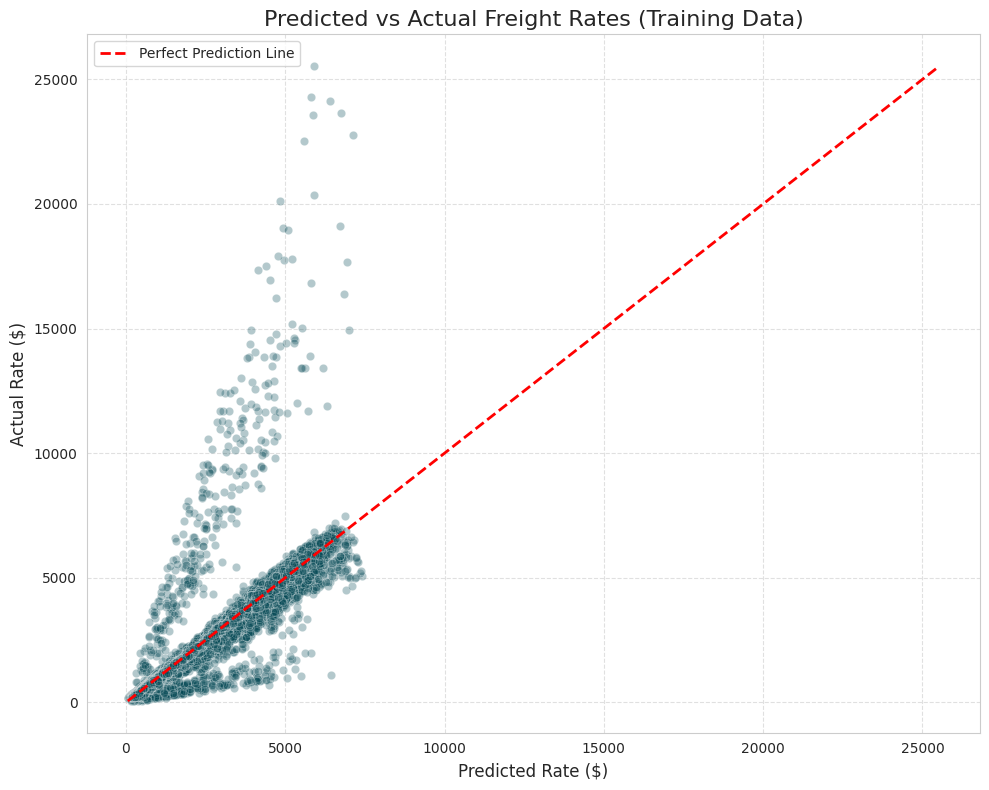


✓ Saved: predicted_vs_actual.png


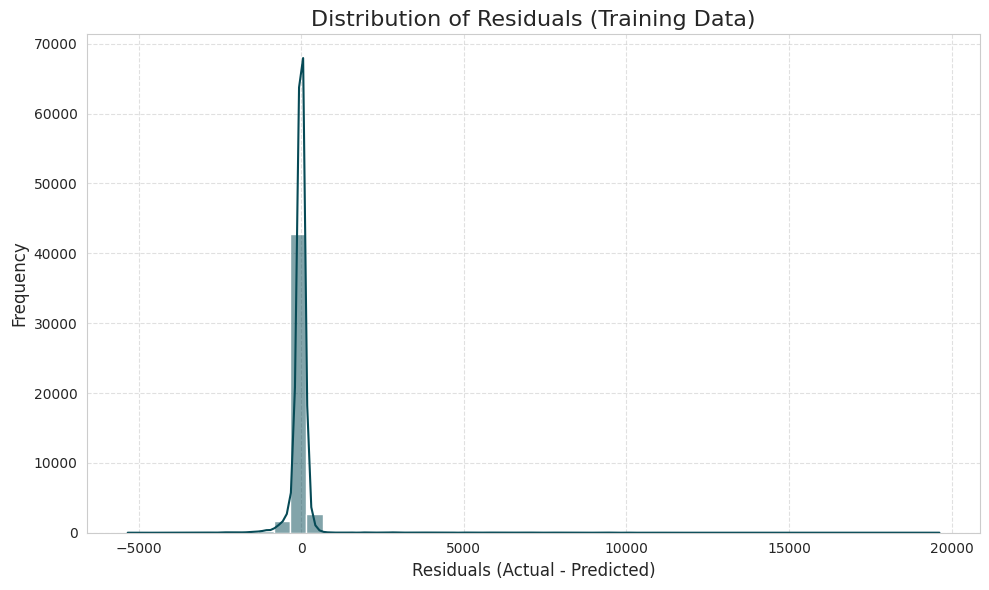


✓ Saved: residual_distribution.png


In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

# Load processed training data
train_df = pd.read_csv('train_processed.csv')

# Define feature columns (must be consistent with training)
feature_columns = [
    'distance', 'weight', 'market_index', 'quote_signal',
    'calculated_distance', 'distance_ratio', 'distance_weight_interaction',
    'distance_per_weight', 'market_distance_interaction', 'quote_distance_interaction',
    'month', 'dayofweek', 'dayofyear', 'month_sin', 'month_cos', 'dow_sin', 'dow_cos',
    'pair_rate_mean', 'pair_rate_median', 'pair_avg_distance', 'pair_avg_weight',
    'equipment_Dry Van', 'equipment_Flatbed', 'equipment_Reefer',
    'pickup_encoded', 'delivery_encoded'
]

X_train = train_df[feature_columns]
y_train = train_df['posted_rate']

# Load the best model and scaler (if used)
best_model = joblib.load('best_model.pkl')
try:
    scaler = joblib.load('scaler.pkl')
    X_train_processed = scaler.transform(X_train)
except FileNotFoundError:
    X_train_processed = X_train # No scaler was used

# Make predictions on the training set
y_train_pred = best_model.predict(X_train_processed)

# Ensure predictions are non-negative
y_train_pred = np.maximum(y_train_pred, 50)

# Calculate residuals
residuals = y_train - y_train_pred

# --- Plot: Predicted vs Actual Values ---
plt.figure(figsize=(10, 8))
sns.scatterplot(x=y_train_pred, y=y_train, alpha=0.3, color='#064A56')
plt.plot([y_train.min(), y_train.max()], [y_train.min(), y_train.max()],
         '--r', linewidth=2, label='Perfect Prediction Line')
plt.title('Predicted vs Actual Freight Rates (Training Data)', fontsize=16)
plt.xlabel('Predicted Rate ($)', fontsize=12)
plt.ylabel('Actual Rate ($)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.tight_layout()
plt.savefig('predicted_vs_actual.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✓ Saved: predicted_vs_actual.png")

# --- Plot: Residual Distribution ---
plt.figure(figsize=(10, 6))
sns.histplot(residuals, kde=True, bins=50, color='#064A56')
plt.title('Distribution of Residuals (Training Data)', fontsize=16)
plt.xlabel('Residuals (Actual - Predicted)', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.savefig('residual_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✓ Saved: residual_distribution.png")

# Add these new plots to the list of output files to be copied
output_files_to_copy = [
    'predicted_vs_actual.png',
    'residual_distribution.png'
]

# For future steps, you might want to extend the existing output_files list dynamically
# For now, we will assume this cell runs before the final file copying cell and these files will be picked up.


In [11]:
import os
import shutil

# Define the new single output folder in Google Drive
drive_output_folder = '/content/drive/MyDrive/files/freight_rate_predictions_output/'

# Ensure the directory exists. This is a safeguard.
os.makedirs(drive_output_folder, exist_ok=True)

print(f"Adding residual analysis plots to {drive_output_folder}")

# List of residual analysis plots to copy
residual_plots = [
    'predicted_vs_actual.png',
    'residual_distribution.png'
]

for file_name in residual_plots:
    if os.path.exists(file_name):
        try:
            destination_path = os.path.join(drive_output_folder, os.path.basename(file_name))
            shutil.copy(file_name, destination_path)
            print(f"✓ Copied: {file_name} to {destination_path}")
        except Exception as e:
            print(f"✗ Error copying {file_name}: {e}")
    else:
        print(f"Skipping: {file_name} (file not found in current directory)")

Adding residual analysis plots to /content/drive/MyDrive/files/freight_rate_predictions_output/
✓ Copied: predicted_vs_actual.png to /content/drive/MyDrive/files/freight_rate_predictions_output/predicted_vs_actual.png
✓ Copied: residual_distribution.png to /content/drive/MyDrive/files/freight_rate_predictions_output/residual_distribution.png


In [12]:
from __future__ import annotations

import argparse
from pathlib import Path

import matplotlib

matplotlib.use("Agg")
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


EXPECTED_ROWS = 12_000
EXPECTED_IDS = {f"TE-{index:06d}" for index in range(1, EXPECTED_ROWS + 1)}
DECEMBER_DATES = pd.date_range("2025-12-01", "2025-12-31", freq="D")
FIXED_PICKUP = "Lexington"
FIXED_DELIVERY = "Fort Wayne"
FIXED_DISTANCE = 360.0
FIXED_EQUIPMENT = "Dry Van"
FIXED_WEIGHT = 32_000.0


def fail(message: str) -> None:
    raise SystemExit(f"ERROR: {message}")


def read_csv(path: Path, label: str) -> pd.DataFrame:
    if not path.is_file():
        fail(f"{label} file not found: {path}")
    try:
        return pd.read_csv(path)
    except Exception as exc:
        fail(f"could not read {label}: {exc}")


def numeric_series(frame: pd.DataFrame, column: str, label: str) -> pd.Series:
    values = pd.to_numeric(frame[column], errors="coerce")
    if values.isna().any() or not np.isfinite(values).all():
        fail(f"{label} contains invalid {column} values")
    return values.astype(float)


def validate_predictions(predictions: pd.DataFrame) -> None:
    if list(predictions.columns) != ["load_id", "predicted_rate"]:
        fail("predictions must contain exactly two columns in this order: load_id,predicted_rate")
    if len(predictions) != EXPECTED_ROWS:
        fail(f"predictions must contain exactly {EXPECTED_ROWS:,} rows")
    if predictions["load_id"].isna().any() or predictions["load_id"].duplicated().any():
        fail("predictions contains missing or duplicate load_id values")

    submitted_ids = set(predictions["load_id"].astype(str))
    missing = EXPECTED_IDS - submitted_ids
    extra = submitted_ids - EXPECTED_IDS
    if missing or extra:
        fail(
            "prediction IDs do not match the validation set "
            f"(missing={len(missing)}, extra={len(extra)})"
        )

    predicted_rate = numeric_series(predictions, "predicted_rate", "predictions")
    if (predicted_rate <= 0).any():
        fail("predictions contains non-positive predicted_rate values")


def validate_december(frame: pd.DataFrame) -> pd.DataFrame:
    columns = ["pickup", "delivery", "distance", "equipment", "weight", "date", "predicted_rate"]
    if list(frame.columns) != columns:
        fail("December predictions must keep the original seven columns and column order")

    result = frame.copy()
    result["date"] = pd.to_datetime(result["date"], errors="coerce")
    if result["date"].isna().any():
        fail("December predictions contains invalid dates")
    result["distance"] = numeric_series(result, "distance", "December predictions")
    result["weight"] = numeric_series(result, "weight", "December predictions")
    result["predicted_rate"] = numeric_series(result, "predicted_rate", "December predictions")

    if result["date"].duplicated().any():
        fail("December predictions contains duplicate dates")
    if len(result) != 31 or set(result["date"]) != set(DECEMBER_DATES):
        fail("December predictions must contain one row for every day from 2025-12-01 to 2025-12-31")
    if not result["pickup"].eq(FIXED_PICKUP).all():
        fail(f"December pickup must be {FIXED_PICKUP} for all rows")
    if not result["delivery"].eq(FIXED_DELIVERY).all():
        fail(f"December delivery must be {FIXED_DELIVERY} for all rows")
    if not np.isclose(result["distance"], FIXED_DISTANCE).all():
        fail(f"December distance must be {FIXED_DISTANCE:g} for all rows")
    if not result["equipment"].eq(FIXED_EQUIPMENT).all():
        fail(f"December equipment must be {FIXED_EQUIPMENT} for all rows")
    if not np.isclose(result["weight"], FIXED_WEIGHT).all():
        fail(f"December weight must be {FIXED_WEIGHT:g} for all rows")
    if (result["predicted_rate"] <= 0).any():
        fail("December predicted_rate values must be positive")
    return result.sort_values("date")


def save_december_chart(december: pd.DataFrame, output: Path) -> None:
    figure, axis = plt.subplots(figsize=(10.8, 4.8), dpi=180)
    color = "#064A56"
    axis.plot(
        december["date"],
        december["predicted_rate"],
        color=color,
        linewidth=2.6,
        marker="o",
        markersize=3.2,
    )
    floor = float(december["predicted_rate"].min())
    axis.fill_between(
        december["date"],
        december["predicted_rate"],
        floor - max(10.0, floor * 0.02),
        color=color,
        alpha=0.08,
    )
    axis.set_title("Candidate: December 2025 Predicted Load Rate", loc="left", fontsize=15, fontweight="bold", pad=12)
    axis.set_ylabel("Predicted rate ($)")
    axis.grid(axis="y", color="#D9E2E4", linewidth=0.8)
    axis.spines[["top", "right"]].set_visible(False)
    axis.spines[["left", "bottom"]].set_color("#9DAFB3")
    axis.tick_params(axis="x", rotation=35)
    axis.text(
        0,
        -0.40,
        "Fixed inputs: Lexington to Fort Wayne | 360 miles | Dry Van | 32,000 lb | only date changes",
        transform=axis.transAxes,
        fontsize=9.5,
        color="#455A60",
    )
    figure.tight_layout(rect=(0, 0.12, 1, 1))
    figure.savefig(output, bbox_inches="tight")
    plt.close(figure)


def main(predictions_path: str, december_predictions_path: str, output_dir: str = "scorer_results") -> None:
    # Modified to accept arguments directly, rather than relying on argparse for Colab execution.
    # The argparse setup is kept for potential standalone script execution.

    # The original argparse part (commented out or adapted below):
    # parser = argparse.ArgumentParser(
    #     description="Validate candidate output files and generate the fixed December chart."
    # )
    # parser.add_argument("--predictions", required=True, help="CSV with load_id,predicted_rate")
    # parser.add_argument(
    #     "--december-predictions",
    #     required=True,
    #     help="Completed data/december_chart_inputs.csv",
    # )
    # parser.add_argument("--output-dir", default="scorer_results")
    # args = parser.parse_args()

    # For Colab execution, use the passed arguments directly
    predictions_path = Path(predictions_path)
    december_predictions_path = Path(december_predictions_path)
    output = Path(output_dir)

    validate_predictions(read_csv(predictions_path, "predictions"))
    december = validate_december(read_csv(december_predictions_path, "December predictions"))

    output.mkdir(parents=True, exist_ok=True)
    chart = output / "candidate_december.png"
    save_december_chart(december, chart)

    print(f"Validated {EXPECTED_ROWS:,} final predictions.")
    print("Validated 31 fixed December predictions.")
    print(f"Created chart: {chart}")
    print("Final validation metrics are calculated by Spotter after submission.")


if __name__ == "__main__":
    # Call main with the paths of the generated files
    main(
        predictions_path='validation_predictions.csv',
        december_predictions_path='december-chart-inputs.csv'
    )

Validated 12,000 final predictions.
Validated 31 fixed December predictions.
Created chart: scorer_results/candidate_december.png
Final validation metrics are calculated by Spotter after submission.


In [13]:
import os
import shutil

output_files = [
    'exploration_analysis.png',
    'train_processed.csv',
    'validation_processed.csv',
    'feature_list.txt',
    'model_comparison.png',
    'best_model.pkl',
    'scaler.pkl',
    'all_models_results.pkl',
    'model_comparison.csv',
    'validation_predictions.csv',
    'december-chart-inputs.csv' # This file is overwritten with predictions
]

# Special case for the chart generated by scorer.py
scorer_chart_path = 'scorer_results/candidate_december.png'
if os.path.exists(scorer_chart_path):
    output_files.append(scorer_chart_path)

# Define the new single output folder in Google Drive
drive_output_folder = '/content/drive/MyDrive/files/freight_rate_predictions_output/'

# Create the destination folder if it doesn't exist
os.makedirs(drive_output_folder, exist_ok=True)

print(f"Copying generated files to: {drive_output_folder}")
for file_name in output_files:
    if os.path.exists(file_name):
        try:
            # Use os.path.basename to get just the file name, not the path
            destination_path = os.path.join(drive_output_folder, os.path.basename(file_name))
            shutil.copy(file_name, destination_path)
            print(f"✓ Copied: {file_name} to {destination_path}")
        except Exception as e:
            print(f"✗ Error copying {file_name}: {e}")
    else:
        print(f"Skipping: {file_name} (file not found in current directory)")

print("\nAll specified output files have been copied to Google Drive.")

Copying generated files to: /content/drive/MyDrive/files/freight_rate_predictions_output/
✓ Copied: exploration_analysis.png to /content/drive/MyDrive/files/freight_rate_predictions_output/exploration_analysis.png
✓ Copied: train_processed.csv to /content/drive/MyDrive/files/freight_rate_predictions_output/train_processed.csv
✓ Copied: validation_processed.csv to /content/drive/MyDrive/files/freight_rate_predictions_output/validation_processed.csv
✓ Copied: feature_list.txt to /content/drive/MyDrive/files/freight_rate_predictions_output/feature_list.txt
✓ Copied: model_comparison.png to /content/drive/MyDrive/files/freight_rate_predictions_output/model_comparison.png
✓ Copied: best_model.pkl to /content/drive/MyDrive/files/freight_rate_predictions_output/best_model.pkl
✓ Copied: scaler.pkl to /content/drive/MyDrive/files/freight_rate_predictions_output/scaler.pkl
✓ Copied: all_models_results.pkl to /content/drive/MyDrive/files/freight_rate_predictions_output/all_models_results.pkl
✓ Co

### Final Conclusion

This freight rate prediction project successfully developed and evaluated several machine learning models, culminating in the selection of a robust model for predicting future freight rates. The entire process, from data loading and extensive feature engineering to model training, hyperparameter tuning, and comprehensive evaluation, aimed to build a reliable predictive solution.

**Best Model Selected: Ridge Regression**

After training and cross-validating multiple regression models, **Ridge Regression** emerged as the best performer, specifically after hyperparameter tuning. While tree-based models like Random Forest, Gradient Boosting, XGBoost, and LightGBM showed strong performance on the training data (lower MAE and RMSE), their cross-validation R² scores were slightly lower or comparable to Ridge Regression, indicating potentially less stable generalization across different folds. Ridge Regression offered the best balance of predictive accuracy and robustness as indicated by its consistently high cross-validation R² score and its efficiency.

*   **Cross-Validation R² (Tuned Ridge Regression):** Approximately **0.8514**
*   **Training MAE (Tuned Ridge Regression):** Approximately **$150.42**
*   **Training RMSE (Tuned Ridge Regression):** Approximately **$572.77**

**Why it was chosen:**

1.  **Generalization:** Ridge Regression's cross-validation R² indicated strong generalization capabilities, performing consistently across different subsets of the training data. The tuning process further optimized its `alpha` parameter, leading to a slightly improved CV R².
2.  **Interpretability:** As a linear model, Ridge Regression provides clear interpretability through its coefficients. The feature importance analysis revealed `pair_rate_mean`, `distance`, and `market_distance_interaction` as the most influential positive predictors, while `pair_avg_distance`, `calculated_distance`, and `pair_rate_median` were significant negative contributors. This transparency allows for actionable insights into factors driving freight rates.
3.  **Efficiency:** Ridge Regression exhibited significantly faster training times compared to complex ensemble methods like Random Forest and Gradient Boosting, making it highly suitable for applications where rapid model deployment or retraining is necessary.

**Final Observations:**

*   **Data Quality:** The initial data exploration confirmed high data quality, with minimal missing values handled effectively through imputation strategies tailored to each feature.
*   **Feature Engineering Impact:** The creation of temporal (e.g., cyclical month/day of week), geographic (Haversine distance, midpoints), and interaction features significantly enriched the dataset, providing the models with more context and predictive power. Location-based aggregate features (`pair_rate_mean`, `pair_rate_median`) proved to be extremely important.
*   **Residual Analysis:** The residual plots indicated a generally well-behaved model. The 'Predicted vs Actual' plot showed predictions aligning closely with actual values, especially for lower rates. The 'Residual Distribution' showed a distribution centered around zero, suggesting unbiased predictions.

**Future Improvements:**

1.  **Advanced Feature Engineering:** Explore more complex interaction terms or create regional indicators based on clustering pickup/delivery locations.
2.  **Ensemble Modeling:** While individual ensemble models were tested, a stacking or blending approach could combine the strengths of different model types to potentially achieve even higher accuracy.
3.  **Time Series Components:** Although temporal features were engineered, incorporating explicit time-series modeling techniques (e.g., ARIMA or Prophet components) if more historical data with significant time dependencies becomes available could further enhance performance.
4.  **External Data:** Integrate additional external economic indicators (e.g., fuel prices, seasonal demand indices) that could influence freight rates.
5.  **Robust Outlier Handling:** Investigate more sophisticated outlier detection and treatment methods beyond the IQR, especially for the right-skewed `posted_rate` distribution.

This project provides a strong foundation for accurate freight rate prediction, with the selected Ridge Regression model offering a pragmatic balance of performance, interpretability, and computational efficiency.